# Validando uma estratégia do zero

**Nível 4 — Prática** · Trilha Wizz Lab

> Processo antes de performance. Evidência antes de confiança.


Os seis gates do manual, aplicados em ordem a uma estratégia — inclusive quando a resposta
é "reprovado".


---

In [1]:
%matplotlib inline

# No Colab, instala o pacote direto do GitHub. Localmente, não faz nada.
import importlib.util, subprocess, sys

if importlib.util.find_spec("wizzlab") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/Gustavofthiesen/wizz-lab.git"], check=True)

from wizzlab import brand, data, metrics, scorecard
from wizzlab.theme import aplicar_tema
from wizzlab import charts

aplicar_tema()
print("Wizz Lab pronto · paleta:", brand.SERIE_PRINCIPAL, brand.SERIE_COMPARACAO)

Wizz Lab pronto · paleta: #2F5D50 #B66A3C


## A ordem importa

Antes de olhar Sharpe, Calmar ou CAGR, integridade e edge líquido são gates
**eliminatórios**.

| Gate | O que responde | Elimina? |
|---|---|---|
| 0 | Integridade do backtest | **Sim** |
| 1 | Edge econômico líquido | **Sim** |
| 2 | Evidência estatística | Não |
| 3 | Generalização | Não |
| 4 | Sobrevivência | Não |
| 5 | Execução | Não |

In [2]:
import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

est = data.gerar_estrategia(semente=42)
r = est.trades.r_multiple.values

## Gate 0 — as auditorias que você precisa ter feito

Estas não são fórmulas: são verificações. Cada `True` abaixo é uma afirmação sua sobre o
próprio backtest, e o gate só faz sentido se você foi honesto ao preenchê-lo.

**Não auditado conta como reprovado** — de propósito.

In [3]:
auditorias = {
    "lookahead": True,          # nenhuma decisão usou informação futura
    "repainting": True,         # o indicador histórico não muda
    "same_bar": True,           # ambiguidade stop/alvo resolvida conservadoramente
    "intrabar": True,           # caminhos intrabar testados
    "timestamp": True,          # fusos e sessões conferidos
    "corporate_action": True,   # ajustes e rolagens verificados
    "survivorship": True,       # universo inclui quem desapareceu
    "data_snooping": False,     # <- ainda não registramos as tentativas
}
metrics.execucao.auditoria_integridade(auditorias)

,auditoria,pergunta,situacao
0,lookahead,Alguma decisao usa informacao que nao existia no instant...,PASS
1,repainting,O indicador historico muda depois que novas barras chegam?,PASS
2,same_bar,"Quando stop e target cabem na mesma barra OHLC, qual oco...",PASS
3,intrabar,O resultado muda ao reconstruir caminhos intrabar plausi...,PASS
4,timestamp,"Horarios, sessoes e fusos estao alinhados ao mercado real?",PASS
5,corporate_action,Precos ajustados e rolagens criam retornos artificiais?,PASS
6,survivorship,O universo historico inclui ativos que desapareceram?,PASS
7,data_snooping,Quantas decisoes foram tomadas olhando o mesmo historico?,FAIL


## Rodando os seis gates

In [4]:
gates = scorecard.avaliar(
    r_multiples=r,
    retornos_diarios=est.diario,
    custo_esperado=0.05,
    integridade=auditorias,
    mdd_tolerado=-0.30,
)
scorecard.tabela(gates)

,gate,criterio,valor,limite,situacao,nota
0,0 · Integridade do backtest,lookahead,1.000000,1.00,PASS,Alguma decisao usa informacao que nao existia no instant...
1,0 · Integridade do backtest,repainting,1.000000,1.00,PASS,O indicador historico muda depois que novas barras chegam?
2,0 · Integridade do backtest,same_bar,1.000000,1.00,PASS,"Quando stop e target cabem na mesma barra OHLC, qual oco..."
3,0 · Integridade do backtest,intrabar,1.000000,1.00,PASS,O resultado muda ao reconstruir caminhos intrabar plausi...
4,0 · Integridade do backtest,timestamp,1.000000,1.00,PASS,"Horarios, sessoes e fusos estao alinhados ao mercado real?"
5,0 · Integridade do backtest,corporate_action,1.000000,1.00,PASS,Precos ajustados e rolagens criam retornos artificiais?
6,0 · Integridade do backtest,survivorship,1.000000,1.00,PASS,O universo historico inclui ativos que desapareceram?
7,0 · Integridade do backtest,data_snooping,0.000000,1.00,FAIL,Quantas decisoes foram tomadas olhando o mesmo historico?
8,1 · Edge econômico líquido,Expectancy líquida (R),0.084154,0.00,PASS,"Condição necessária, não suficiente."
9,1 · Edge econômico líquido,Profit factor,1.133243,1.20,FAIL,"1,1 é frágil; 1,3-1,5 começa a interessar."


In [5]:
scorecard.veredito(gates)

Gate 0 · Integridade do backtest                             FAIL (88%)
Gate 1 · Edge econômico líquido                              FAIL (50%)
Gate 2 · Evidência estatística                               FAIL (25%)
Gate 3 · Generalização                                       FAIL (50%)
Gate 4 · Sobrevivência                                       FAIL (75%)
Gate 5 · Execução                                             FAIL (0%)
VEREDITO                            REPROVADO — gate eliminatório: 0, 1
dtype: object

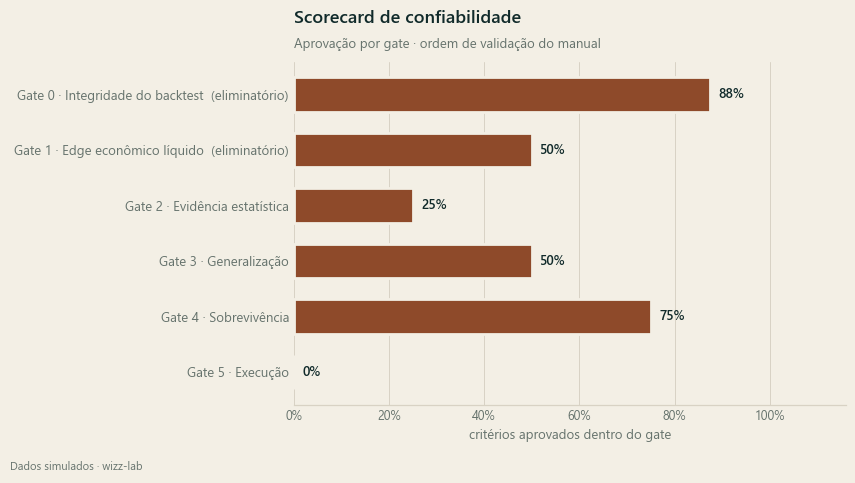

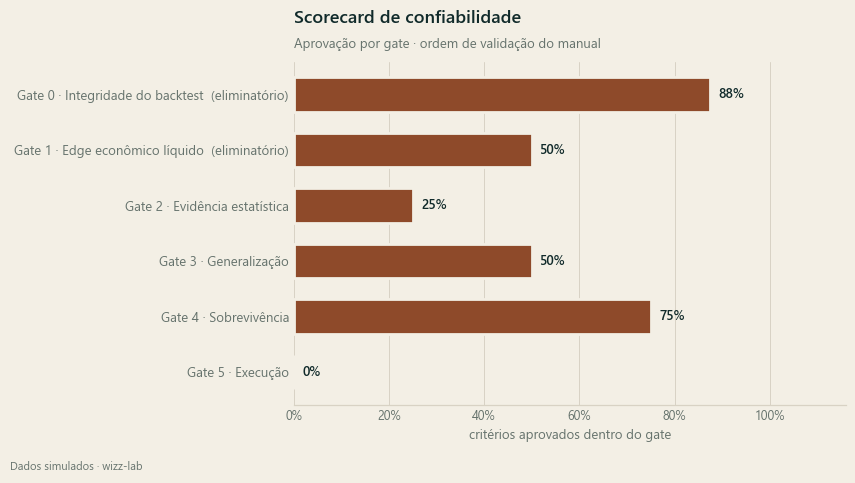

In [6]:
fig, ax = charts.gates(gates, fonte="Dados simulados · wizz-lab")
fig

## Lendo o veredito

O Gate 0 reprovou por uma razão só: não registramos quantas configurações foram testadas.
Isso basta para invalidar tudo que vem depois — e é assim que deve ser. Um backtest cujo
processo de pesquisa não foi rastreado não tem como ser defendido.

Note também que o **score composto vai a zero** quando um gate eliminatório reprova:

In [7]:
print("Score composto:", scorecard.composite_reliability_score(gates))

Score composto: 0.0


> **Por que zero e não uma média ponderada.** Porque uma média deixaria o Gate 4 excelente
> compensar o Gate 0 reprovado — e não compensa. O manual é explícito ao pedir que um
> score composto não finja independência entre dimensões.
>
> Este número serve para acompanhar a própria evolução no tempo. **Nunca para convencer
> alguém.**

## Corrigindo e rodando de novo

Vamos supor que você registrou as tentativas (foram 12, todas de uma família só) e pode
marcar a auditoria como feita.

In [8]:
registro = [{"familia": "janela do indicador", "valor": v} for v in range(1, 13)]
print(metrics.generalizacao.research_trials(registro).to_string())

auditorias["data_snooping"] = True
gates = scorecard.avaliar(r, est.diario, custo_esperado=0.05,
                          integridade=auditorias, mdd_tolerado=-0.30)
scorecard.veredito(gates)

trials_declarados      12
janela do indicador    12


Gate 0 · Integridade do backtest                         PASS (100%)
Gate 1 · Edge econômico líquido                           FAIL (50%)
Gate 2 · Evidência estatística                            FAIL (25%)
Gate 3 · Generalização                                    FAIL (50%)
Gate 4 · Sobrevivência                                    FAIL (75%)
Gate 5 · Execução                                          FAIL (0%)
VEREDITO                            REPROVADO — gate eliminatório: 1
dtype: object

Gate 0 passa — e agora o Gate 1 vira o bloqueio. A margem de segurança de custo está
abaixo de 2x e o profit factor abaixo de 1,20.

**Esse é o desfecho mais comum de uma validação séria, e não é um fracasso.** É a
informação de que a estratégia, como está, não tem folga para o mundo real. As saídas são
reduzir custo, aumentar o edge por trade ou reduzir o giro — não afrouxar o critério.

## O checklist final do manual

Quando eu começaria a confiar? Não é preciso que a estratégia seja perfeita. É preciso que
as explicações alternativas tenham sido tratadas de forma explícita.

In [9]:
checklist = {
    "Sem lookahead, repaint, survivorship e ambiguidade de execução": True,
    "Expectancy líquida positiva após custos conservadores": True,
    "Bootstrap mostra que o edge não é um ponto frágil": False,
    "N efetivo suficiente e dependência tratada": True,
    "OOS e walk-forward preservam parcela útil do edge": False,
    "PBO/DSR e trials não sugerem seleção excessiva": True,
    "Parâmetros formam platôs e resistem a perturbações": True,
    "O indicador mostra informação por quantis, IC ou forward returns": True,
    "Monte Carlo produz MDD e streaks compatíveis com o sizing": False,
    "Custos, fills, turnover e capacidade viáveis": False,
    "Live/forward test dentro das distribuições previstas": False,
}
print(f"Aprovação: {metrics.generalizacao.robustness_pass_rate(checklist):.0%}")
for item, ok in checklist.items():
    print(f"  [{'x' if ok else ' '}] {item}")

Aprovação: 55%
  [x] Sem lookahead, repaint, survivorship e ambiguidade de execução
  [x] Expectancy líquida positiva após custos conservadores
  [ ] Bootstrap mostra que o edge não é um ponto frágil
  [x] N efetivo suficiente e dependência tratada
  [ ] OOS e walk-forward preservam parcela útil do edge
  [x] PBO/DSR e trials não sugerem seleção excessiva
  [x] Parâmetros formam platôs e resistem a perturbações
  [x] O indicador mostra informação por quantis, IC ou forward returns
  [ ] Monte Carlo produz MDD e streaks compatíveis com o sizing
  [ ] Custos, fills, turnover e capacidade viáveis
  [ ] Live/forward test dentro das distribuições previstas


---

## O princípio final

> Uma estratégia não precisa parecer infalível. Precisa ser rastreável, coerente e
> intelectualmente honesta.

O que este notebook faz não é aprovar ou reprovar. É **deixar registrado** o que foi
testado, o que passou e o que não passou — para que a conversa seja sobre evidência, e não
sobre convicção.

---

### Bloco de transparência

**Natureza:** educacional · **Dados:** simulados e reprodutíveis por semente ·
**Código:** aberto em [wizz-lab](https://github.com/Gustavofthiesen/wizz-lab)

Este material apresenta um processo de estudo, com finalidade educacional. Não
constitui recomendação individualizada, oferta ou promessa de retorno. Premissas podem
estar erradas e resultados passados não garantem resultados futuros.